In [40]:
%load_ext autoreload
%autoreload 2

import platform
import pandas as pd
import os
import sys

system = platform.system()
if system == 'Linux':
    home = '/home/gerard/'
elif system == 'Darwin':
    home = '/Users/gerard/'
elif system == "Windows":
    home = 'C:/Users/cviko/'


try:
    sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *
except:
    path2add = home + 'analysis/confocal/src'
    sys.path.append(path2add)
    from data_processing import *
    from utils import *
    from plotter import *
    from colocalization import *

home = home + 'data/confocal/'



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
def df_separator(df):
    # 5x vs 1x
    keys = ['5x', '1x', '5x.alpha_', '5x.alphaprime_','5x.gamma_', '1x.alpha_', '1x.alphaprime_','1x.gamma_']
    dict_results = dict.fromkeys(keys) 
    for k in keys:
        ks = k.split('.')
        if len(ks) == 1:
            dict_results[k] = df[df['name'].str.contains(k, case=False, na=False)]
        else:
            dict_results[k] = df[
                            df['name'].str.contains(ks[0], case=False, na=False) &
                            df['name'].str.contains(ks[1], case=False, na=False)
                                                    ]
    return(dict_results)


In [79]:

user = 'Carmina'
dates = [
   # '2026_06_05',
    '2026_06_15', 
    '2026_06_25'
    ]
csv_files = [
    #'coloc_results', #coloc_results_2_raw',#'coloc_results_2', #'coloc_results
    'coloc_results',
    'coloc_results',

]

rows2drop = [
           # [],
            [
                'dec02_5x_brain3gamma_R8', 
                'dec02_5x_brain4alpha_L16' 
            ],
            []
                ]



df_list = [] 
for i, date in enumerate(dates):
    path_csv = home + date + '_' + user + f'/{csv_files[i]}.csv'
    df = pd.read_csv(path_csv)

    #TO EXCLUDE SOME ROWS:
    if rows2drop[i]:
        for name in rows2drop[i]:
   
            df = df.drop(df[df["name"] == name].index).reset_index(drop=True)
    ###########
    df_list.append(df)

pooled = (
    pd.concat(df_list, keys=dates, names=["date"])
    .reset_index(level="date")      # moves 'date' level out of the index into a column
    .reset_index(drop=True)         # replaces the remaining old-index level with plain 0..n
)
print(pooled.columns)
print(pooled['date'])
print(pooled['name'])






Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       'MB_total_pearson_r HSP-Mito', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_pearson_r HSP-Mito',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_pearson_r HSP-Mito', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', '

In [71]:
#pooled[['name','MB_total_pearson_r HSP-Mito','MB_syn_pearson_r HSP-Mito','MB_non_syn_pearson_r HSP-Mito']]
#pooled[['name','MB_total_enrichment','MB_total_odds_ratio']]
pooled[['date','name','snr_min_HSP_Mito','MB_total_enrichment','MB_total_odds_ratio']]


,date,name,snr_min_HSP_Mito,MB_total_enrichment,MB_total_odds_ratio
0,2026_06_05,dec02_5x_brain1alphaprime_L,22.143,1.158,1.200
1,2026_06_05,dec02_5x_brain1gamma_L,63.429,1.081,1.097
2,2026_06_05,dec02_5x_brain1gamma_R,40.620,1.067,1.079
3,2026_06_05,dec02_5x_brain2alphaprime_L,78.370,1.022,1.026
4,2026_06_05,dec02_5x_brain2gamma_L,87.543,1.015,1.017
5,2026_06_05,dec02_5x_brain3alphaprime_L,68.539,1.028,1.034
6,2026_06_05,dec02_5x_brain3alpha_L,73.460,1.020,1.023
7,2026_06_05,dec02_5x_brain3gamma_L,42.914,1.025,1.031
8,2026_06_05,dec02_5x_brain3alphaprime_R,82.575,1.049,1.059
9,2026_06_05,dec02_5x_brain3alpha_R,89.835,1.040,1.046


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'snr_BRP', 'snr_HSP', 'snr_Mito',
       'snr_min_HSP_Mito']

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'MB_total_fraction of HSP in Mito',
       'MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 'MB_syn_fraction of HSP in Mito',
       'MB_syn_fraction of Mito in HSP', 'MB_syn_odds_ratio',
       'MB_syn_enrichment', 'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap', <-----------
       'MB_non_syn_share of total HSP-Mito overlap',<-----------
       'MB_syn_HSP-Mito colocalization density',<-----------
       'MB_non_syn_HSP-Mito colocalization density',<-----------
       
       
        'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],


Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 
       
       'density_HSP_syn', <-----------
       'density_HSP_non_syn', <-----------
       'density_Mito_syn', <-----------
       'density_Mito_non_syn',<-----------
       
       
       'MB_total_fraction of HSP in Mito', 'MB_total_fraction of Mito in HSP',
       'MB_total_odds_ratio', 'MB_total_enrichment',
       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP',
       'MB_syn_odds_ratio', 'MB_syn_enrichment',
       'MB_non_syn_fraction of HSP in Mito',
       'MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')

Index(['date', 'name', 'mask_HSP', 'mask_mito', 'mask_BRP', 'prop_MB_BRP',
       'prop_MB_HSP', 'prop_MB_Mito', 'prop_MB-HSP_in_syn',
       'prop_MB-Mito_in_syn', 'density_HSP_syn', 'density_HSP_non_syn',
       'density_Mito_syn', 'density_Mito_non_syn',
       
       'MB_total_pearson_r HSP-Mito', <-----------
       
       'MB_total_fraction of HSP in Mito','MB_total_fraction of Mito in HSP', 'MB_total_odds_ratio',
       'MB_total_enrichment', 
       
       'MB_syn_pearson_r HSP-Mito', <-----------

       'MB_syn_fraction of HSP in Mito', 'MB_syn_fraction of Mito in HSP','MB_syn_odds_ratio','MB_syn_enrichment',
       
       'MB_non_syn_pearson_r HSP-Mito', <-----------
       
       'MB_non_syn_fraction of HSP in Mito','MB_non_syn_fraction of Mito in HSP', 'MB_non_syn_odds_ratio',
       'MB_non_syn_enrichment', 
       
       'MB_syn_share of total HSP-Mito overlap',
       'MB_non_syn_share of total HSP-Mito overlap',
       'MB_syn_HSP-Mito colocalization density',
       'MB_non_syn_HSP-Mito colocalization density', 'snr_BRP', 'snr_HSP',
       'snr_Mito', 'snr_min_HSP_Mito'],
      dtype='str')


===== df_list[0] — 5x vs 1x (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9714
  p-value     = 0.9081
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9896
  p-value     = 0.9925
  → Data look approximately normal

MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 5.3722
p-value   = 0.0039
→ Variances differ significantly

Kruskal-Wallis test
H statistic = 8.8278
p-value     = 0.0317
→ Significant differences exist between groups

MB_syn_fraction of HSP in Mito_5x vs MB_non_syn_fraction of HSP in Mito_5x: p_adj = 0.2652 ns
MB_syn_fraction of HSP in Mito_5x vs MB_syn_fraction of HSP in Mito_1x: p_adj = 0.2652 ns
MB_syn_fraction of HSP in Mito_5x vs MB_n

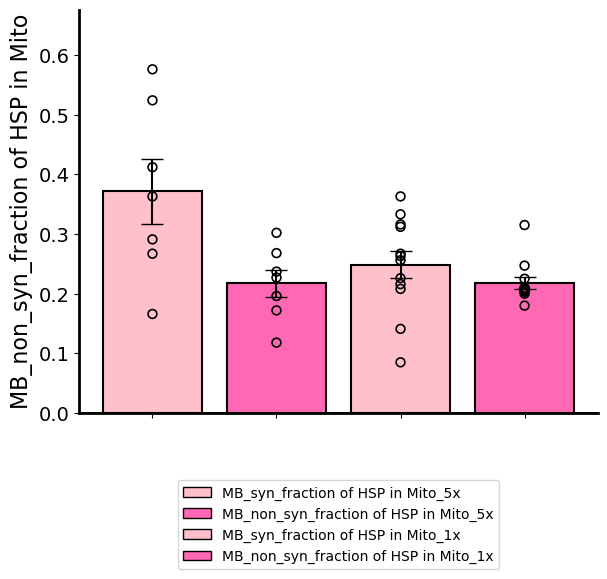


===== df_list[0] — 5x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x
  W statistic = 0.9714
  p-value     = 0.9081
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x
  W statistic = 0.9896
  p-value     = 0.9925
  → Data look approximately normal

Brown-Forsythe test
Statistic = 3.9989
p-value   = 0.0687
→ Variances are not significantly different

One-way ANOVA
F statistic = 6.6969
p-value     = 0.0238
→ Significant differences exist between groups


Effect size
Eta squared (η²) = 0.3582
Effect size interpretation: large
                            Multiple Comparison of Means - Tukey HSD, FWER=0.05                             
                group1                              group2              meandiff p-adj  lower  upper  reject
------------------------------------------------------------------------------------------------------------
MB_non_syn_fraction of HSP in Mito_5x MB_syn_fraction of HSP in

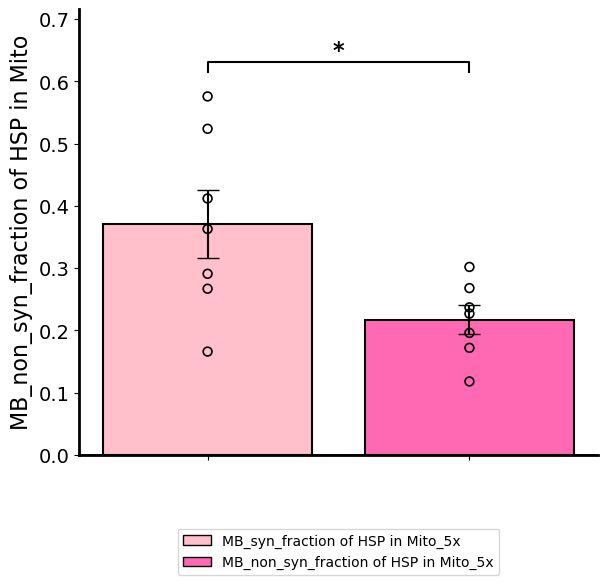


===== df_list[0] — 1x only (pooled, all regions combined) =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_1x
  W statistic = 0.9575
  p-value     = 0.7481
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_1x
  W statistic = 0.7058
  p-value     = 0.0010
  → Significant deviation from normality

Brown-Forsythe test
Statistic = 6.0712
p-value   = 0.0220
→ Variances differ significantly

Mann-Whitney U test
U statistic = 105.5000
p-value     = 0.0562
→ No significant difference detected

  Rank-biserial r = -0.4653
  Effect size: medium

group: MB_syn_fraction of HSP in Mito_1x, mean: 0.24883333333333332, sem: 0.02318203109428865
group: MB_non_syn_fraction of HSP in Mito_1x, mean: 0.21783333333333332, sem: 0.009921535601249875


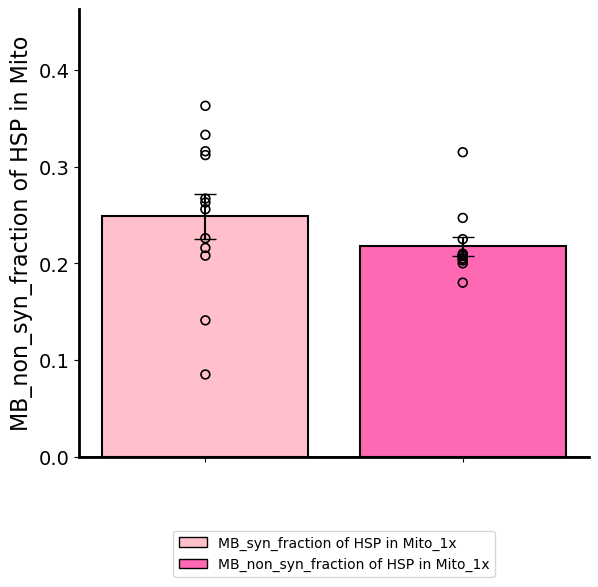


===== df_list[0] — 5x only by subregion =====

---------- STATS ----------
MB_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alpha_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_non_syn_fraction of HSP in Mito_5x.alphaprime_
  Skipped: only 2 sample(s) (need >= 3 for Shapiro-Wilk)

MB_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8434
  p-value     = 0.2230
  → Data look approximately normal

MB_non_syn_fraction of HSP in Mito_5x.gamma_
  W statistic = 0.8830
  p-value     = 0.3333
  → Data look approximately normal

Brown-Forsythe test
Statistic = 0.6246
p-value   = 0.6866
→ Variances are not significantly different

One-way ANOVA
F statistic = 1.4789
p-value     = 0.2962
→ No significant differences detected


Effect size
Eta squared (η²) = 0.4803
Effect size interpretat

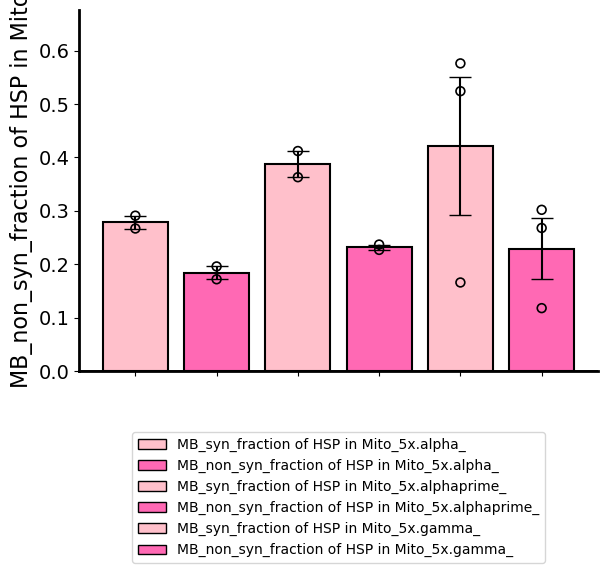

In [82]:


colmns2plot = ['MB_syn_fraction of HSP in Mito', 'MB_non_syn_fraction of HSP in Mito']
#colmns2plot = ['MB_syn_fraction of Mito in HSP', 'MB_non_syn_fraction of Mito in HSP']

#colmns2plot = ['MB_syn_enrichment','MB_non_syn_enrichment']
#colmns2plot = ['MB_syn_odds_ratio', 'MB_non_syn_odds_ratio']
#colmns2plot = ['MB_syn_share of total HSP-Mito overlap', 'MB_non_syn_share of total HSP-Mito overlap',]
#colmns2plot = ['MB_syn_HSP-Mito colocalization density','MB_non_syn_HSP-Mito colocalization density']

#colmns2plot = ['density_HSP_syn','density_HSP_non_syn']
#colmns2plot = ['density_Mito_syn','density_Mito_non_syn']
#colmns2plot =['MB_syn_pearson_r HSP-Mito', 'MB_non_syn_pearson_r HSP-Mito']

#colmns2plot = ['prop_MB-Mito_in_syn']
df_list = [
        #df_raw,
        #df_deconv,
        # df_deconv_blind2, 
        # df_deconv_blind4,
        pooled, 
        # df_deconv_blind20,
                
         ]
colors = [["pink","hotpink"],["skyblue","royalblue"],["lightgreen","seagreen"],["gold","darkorange"]]


# '5x'/'1x' are pooled totals; the six '.'-keys are per-subregion breakdowns of the
# SAME rows (e.g. '5x.alpha_' rows are a subset of '5x' rows). Mixing pooled and
# subregion groups in one fast_plotter call would run ANOVA/Tukey on non-independent
# groups, so each combination below is plotted separately.
plot_configs = [
   ("5x vs 1x (pooled, all regions combined)", ['5x', '1x']),
    #("5x vs 1x by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_',
    #                            '1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
    ("5x only (pooled, all regions combined)", ['5x']),
   ("1x only (pooled, all regions combined)", ['1x']),
    ("5x only by subregion", ['5x.alpha_', '5x.alphaprime_', '5x.gamma_']),
    #("1x only by subregion", ['1x.alpha_', '1x.alphaprime_', '1x.gamma_']),
]

for j,df in enumerate(df_list):
    df_dict = df_separator(df)

    for title, key_group in plot_configs:
        col_data = {}
        new_col_list = []
        for k in key_group:
            df_k = df_dict[k]
            for col in colmns2plot:
                new_col = f"{col}_{k}"
                new_col_list.append(new_col)
                # reset_index: each key's rows keep their original df index (disjoint
                # across keys), so assigning straight into a DataFrame would align on
                # that index and turn every group but the first into all-NaN columns.
                col_data[new_col] = df_k[col].reset_index(drop=True)
        all_df = pd.concat(col_data, axis=1)

        print(f"\n===== df_list[{j}] — {title} =====")

        # one color per column-type in colmns2plot, repeated once per key in key_group
        # (works for any combination of len(colmns2plot)/len(key_group), unlike a
        # fixed /2 divisor which breaks when colmns2plot has an odd length or 1 entry)
        bar_color = colors[j][:len(colmns2plot)] * len(key_group)
        fast_plotter(new_col_list, df= all_df, ylabel=col,  bar_color=bar_color,  quietStats=False, figsize=(6,6), legend=True)
